In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib
import warnings
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('C:Downloads/Karina/spam.csv', encoding='latin-1')
df1 = df

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
df.shape

(5572, 5)

In [8]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [9]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [10]:
print(df['label'].unique())

['ham' 'spam']


In [11]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [12]:
df = df.fillna(df['label'].mode()[0])

In [13]:
le = LabelEncoder()
df['label_num'] = le.fit_transform(df['label'])

In [14]:
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [15]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = text.strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)

In [16]:
df.head()

,label,message,label_num,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,0,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,nah i dont think he goes to usf he lives aroun...


In [17]:
x = df['clean_message']
y = df['label_num']

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=5, stratify=y)

In [19]:
print(Y_train.value_counts())
print(Y_test.value_counts())

label_num
0    3859
1     598
Name: count, dtype: int64
label_num
0    966
1    149
Name: count, dtype: int64


In [20]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

In [21]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, Y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_acc  = accuracy_score(Y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.968609865470852


In [22]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, Y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc  = accuracy_score(Y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9659192825112107


In [23]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, Y_train)
rf_pred = rf_model.predict(X_test_tfidf)
rf_acc  = accuracy_score(Y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9766816143497757


In [24]:
mse = mean_squared_error(Y_test, lr_pred)
print("MSE:", mse)

mae = mean_absolute_error(Y_test, lr_pred)
print("MAE:", mae)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(Y_test, lr_pred)
print("R2 Score:", r2)

MSE: 0.034080717488789235
MAE: 0.034080717488789235
RMSE: 0.18460963541697717
R2 Score: 0.7056289688329374


In [25]:
print(classification_report(Y_test, lr_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [25]:
feature_names = tfidf.get_feature_names_out()
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_[0]
})

importance["Importance"] = abs(importance["Coefficient"])
importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(20))

       Feature  Coefficient  Importance
327       call     4.654362    4.654362
2558       txt     4.626601    4.626601
766       free     3.967845    3.967845
2275      text     3.806089    3.806089
2427        to     3.270814    3.270814
2212      stop     3.156910    3.156910
1508    mobile     2.895351    2.895351
1665       now     2.692902    2.692902
428      claim     2.637983    2.637983
786       from     2.579287    2.579287
1973     reply     2.513610    2.513610
2970      your     2.350261    2.350261
2794       win     2.281980    2.281980
1915     prize     2.233416    2.233416
1568        my    -2.147874    2.147874
1440        me    -2.039497    2.039497
412       chat     2.035776    2.035776
1768        or     1.986228    1.986228
2924  you have     1.968859    1.968859
2826       won     1.952486    1.952486


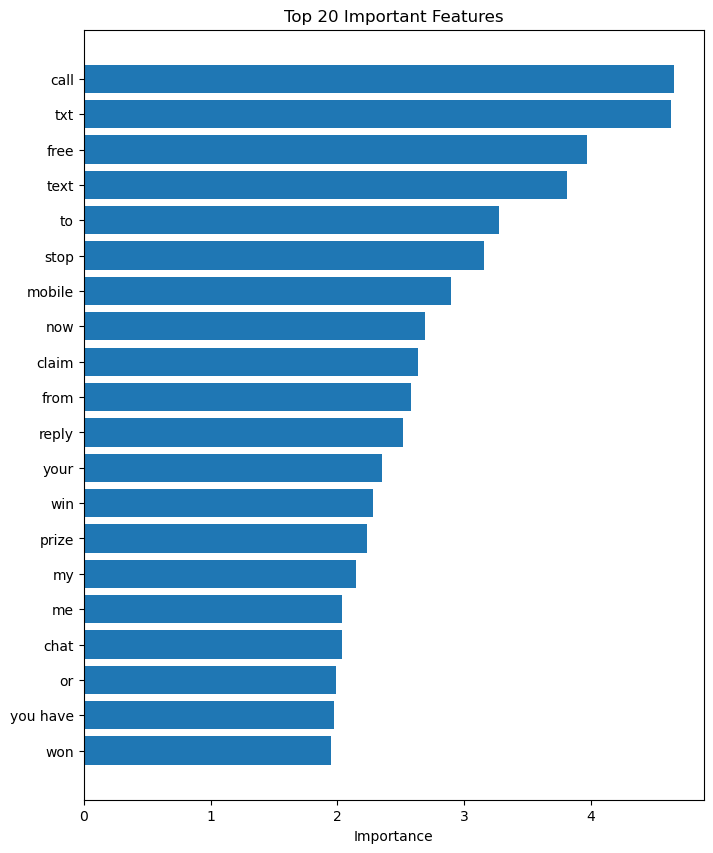

In [26]:
top_features = importance.head(20)

plt.figure(figsize=(8, 10))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.title("Top 20 Important Features")
plt.gca().invert_yaxis()
plt.show()

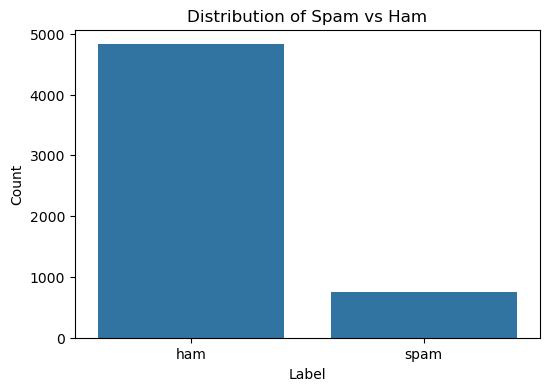

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df)
plt.title("Distribution of Spam vs Ham")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

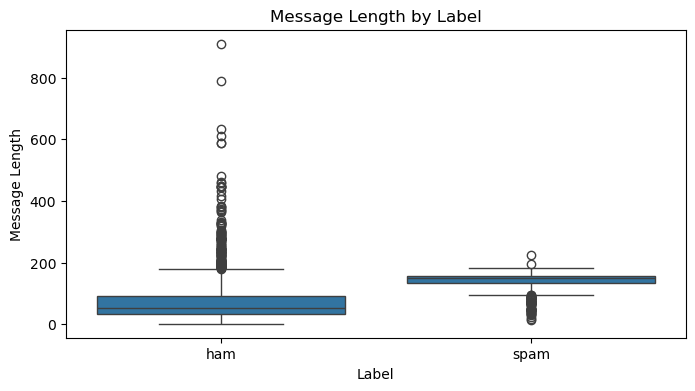

In [28]:
df['msg_length'] = df['message'].apply(len)

plt.figure(figsize=(8, 4))
sns.boxplot(x='label', y='msg_length', data=df)
plt.title("Message Length by Label")
plt.xlabel("Label")
plt.ylabel("Message Length")
plt.show()

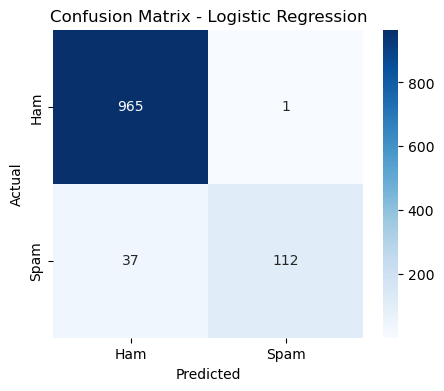

In [29]:
cm = confusion_matrix(Y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

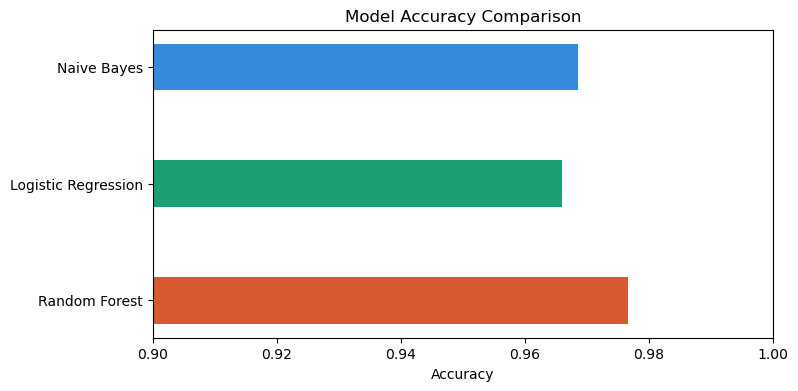

In [30]:
model_names = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
accuracies  = [nb_acc, lr_acc, rf_acc]

plt.figure(figsize=(8, 4))
plt.barh(model_names, accuracies, color=['#378ADD', '#1D9E75', '#D85A30'], height=0.4)
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlim(0.9, 1.0)
plt.gca().invert_yaxis()
plt.show()

In [31]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_tfidf, Y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [32]:
pred = grid.predict(X_test_tfidf)

In [33]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'solver': 'liblinear'}
0.9816000060394681


In [34]:
mse = mean_squared_error(Y_test, pred)
print("MSE:", mse)

mae = mean_absolute_error(Y_test, pred)
print("MAE:", mae)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(Y_test, pred)
print("R2 Score:", r2)

MSE: 0.01883408071748879
MAE: 0.01883408071748879
RMSE: 0.13723731532454572
R2 Score: 0.8373212722497811


In [36]:
print("model saved successfully")

model saved successfully


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, Y_train)
print("✅ Pipeline trained!")

✅ Pipeline trained!


In [38]:
import joblib

joblib.dump(pipeline, "spam_model.pkl")
print("✅ spam_model.pkl saved!")

✅ spam_model.pkl saved!


In [39]:
# Agar tfidf_vectorizer.pkl bhi chahiye
tfidf = pipeline.named_steps['tfidf']
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("✅ tfidf_vectorizer.pkl saved!")

✅ tfidf_vectorizer.pkl saved!
